In [2]:
import sys
from pathlib import Path
import os 
N_THREADS = 8 #optimal thread config for Samwise and Frodo nodes of the SCF cluster
os.environ.update({
    "MKL_DEBUG_CPU_TYPE":   "5",
    "MKL_THREADING_LAYER":  "INTEL",
    "MKL_DYNAMIC":          "FALSE",
    "OMP_DYNAMIC":          "FALSE",
    "MKL_NUM_THREADS":      str(N_THREADS),
    "OMP_NUM_THREADS":      str(N_THREADS),
    "KMP_AFFINITY":         "granularity=fine,compact,1,0",
    "KMP_BLOCKTIME":        "1",
    "OPENBLAS_NUM_THREADS": "1",
    "BLIS_NUM_THREADS":     "1",
    "NUMEXPR_NUM_THREADS":  "1",
})

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys, json
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

_HERE = Path(".").resolve()
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

from plotting import plot_racedriver_memory_time, print_hit_rate_table

JSON_PATH         = "/accounts/projects/mahoneymw/ram900/C/TNrNLA/Numerical_Experiments/Figure1_TDVPPartition/jsons/Collaterunning.json"
DENSE_SPARSE_JSON = str(_HERE / "data" / "DENSE_SPARSE3.json")

print(f"Loading JSON from {JSON_PATH}")
with open(JSON_PATH, "r", encoding="utf-8") as f:
    loaded = json.load(f)

EXCLUDE_CHI = {8, 2, 16}
loaded_filtered = {**loaded, "records": [r for r in loaded["records"] if r["chi"] not in EXCLUDE_CHI]}

print(f"status     : {loaded.get('status')}")
print(f"cases done : {loaded.get('cases_done')} / {loaded.get('cases_total')}")
print(f"n_values   : {loaded['base_cfg'].get('n_values')}")
print(f"chi_values : {loaded['base_cfg'].get('chi_values')}  →  excluding {EXCLUDE_CHI}")
print_hit_rate_table(loaded_filtered)

Loading JSON from /accounts/projects/mahoneymw/ram900/C/TNrNLA/Numerical_Experiments/Figure1_TDVPPartition/jsons/Collaterunning.json
status     : running
cases done : 218 / 320
n_values   : [10, 20, 30, 40, 50, 60, 70, 80]
chi_values : [1, 2, 4, 8]  →  excluding {8, 16, 2}
  n  |  χ= 1  χ= 4
------------------
  10 | 10/10  10/10 
  20 | 10/10  10/10 
  30 | 10/10  10/10 
  40 | 10/10  10/10 
  50 | 10/10  9/10 
  60 | 6/10  9/10 
  70 | 2/10  10/10 


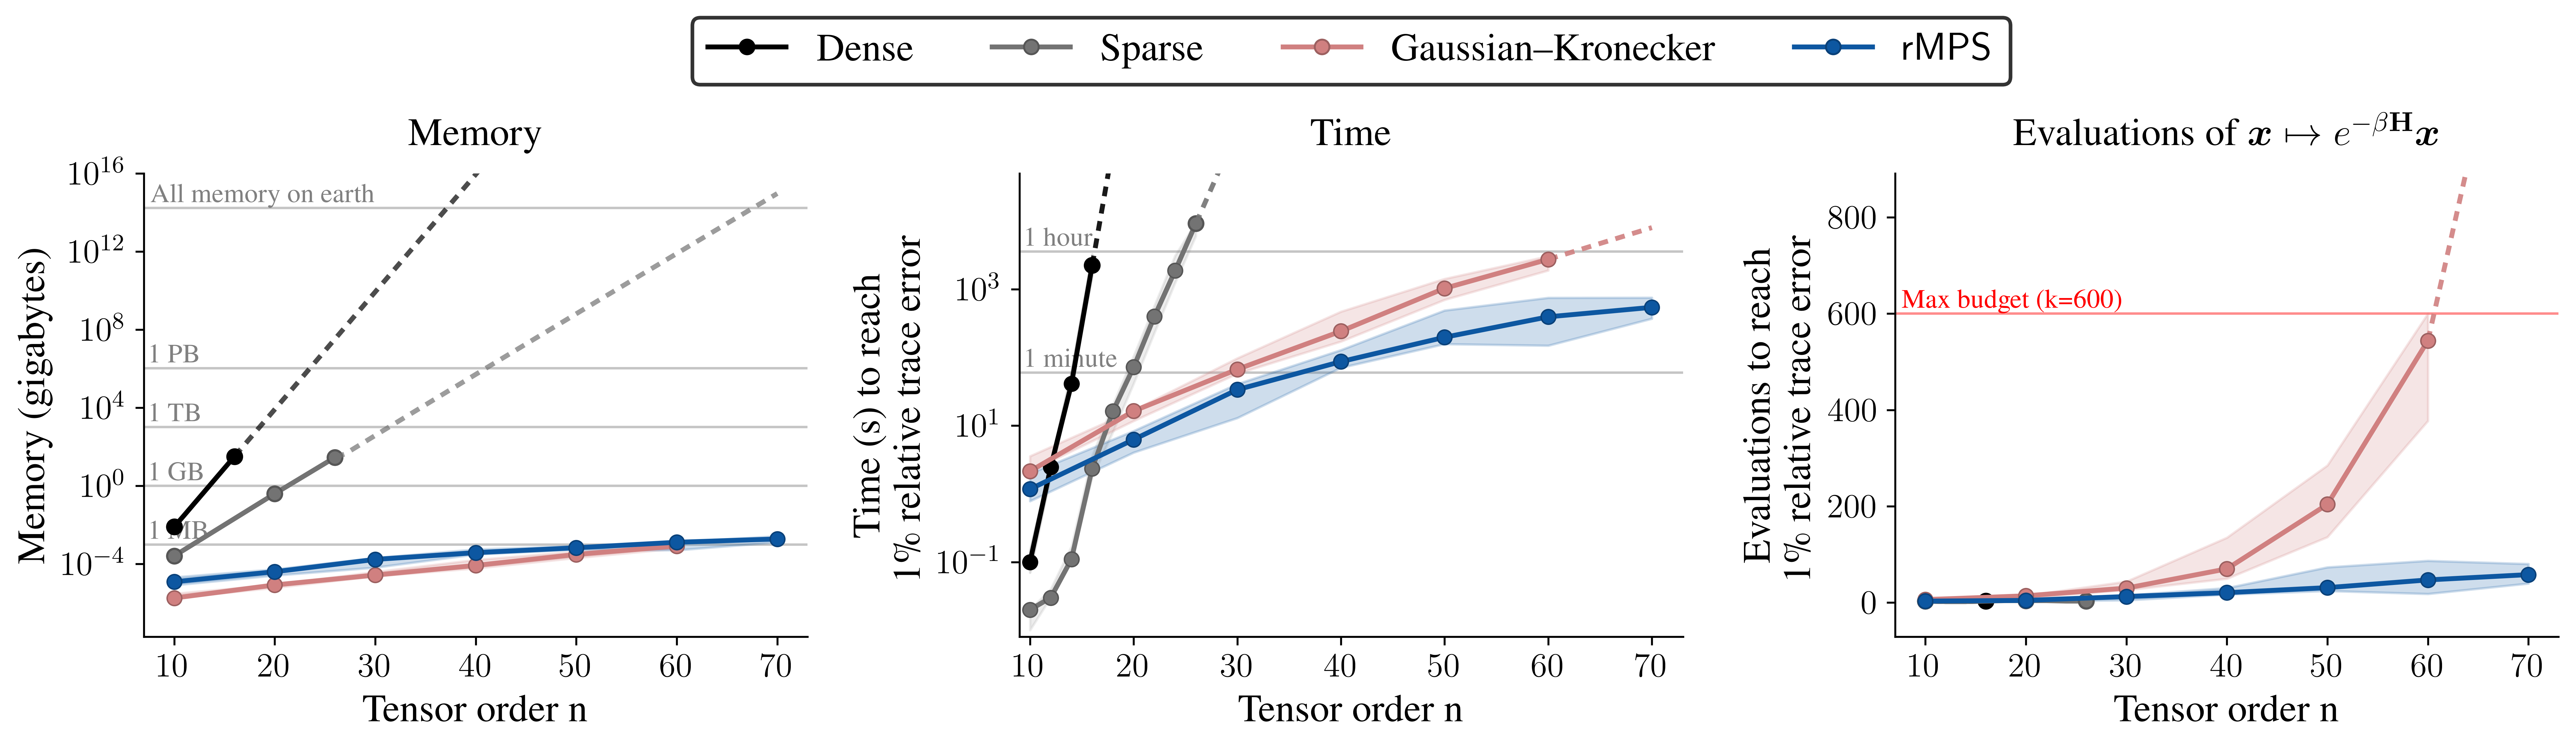

In [11]:
fig, axes = plot_racedriver_memory_time(
    loaded_filtered,
    cmap                = "Blues",
    cmap_lo             = 0.4,
    cmap_hi             = 0.85,
    mode                = "median_quantile",
    marker_every        = 1,
    dense_upperbound_n  = 16,
    sparse_upperbound_n = 26,
    dense_sparse_json   = DENSE_SPARSE_JSON,
    kmax                = loaded["base_cfg"].get("kmax"),
    budget_time_s       = 60.0,
    show                = True,
)
# fig.savefig(_HERE / "figures" / "Fig1.pdf", bbox_inches="tight")

---
### Run


In [9]:
from experiment import run_experiment

J    = 1.0
h    = 8.0
beta = 0.5
b_shift = None

n_values   = list(range(10, 80, 10))
chi_values = [1,4]

kmax        = 600
k_init      = 1
k_step      = 1
k_step_chi1 = 4
target      = 0.01
n_trials    = 20

dt_divisor        = None
dt_divisor_factor = 5.0
gse_k_kr          = 3
gse_k_rmps        = 2
tdvp_krylov_depth = 128
epsEnrich         = 1e-14
epsSRC            = 1e-14
tdvp_cutoff       = 1e-14

sample_seed       = 3234
oracle_seed       = 901234
trial_seed_stride = 1_000_003

_json_dir = _HERE / "data" / "jsons"
_json_dir.mkdir(exist_ok=True)
_now = datetime.now()
live_json_path = str(_json_dir / f"exp1_n{min(n_values)}to{max(n_values)}_live_{_now:%m%y}_{_now.hour}:{_now.minute}.json")
print(f"Output → {live_json_path}")

out = run_experiment(
    n_values          = n_values,
    chi_values        = chi_values,
    J                 = J,
    h                 = h,
    beta              = beta,
    b_shift           = b_shift,
    kmax              = kmax,
    k_init            = k_init,
    k_step            = k_step,
    k_step_chi1       = k_step_chi1,
    target            = target,
    n_trials          = n_trials,
    dt_divisor        = dt_divisor,
    dt_divisor_factor = dt_divisor_factor,
    gse_k_kr          = gse_k_kr,
    gse_k_rmps        = gse_k_rmps,
    tdvp_krylov_depth = tdvp_krylov_depth,
    epsEnrich         = epsEnrich,
    epsSRC            = epsSRC,
    tdvp_cutoff       = tdvp_cutoff,
    sample_seed       = sample_seed,
    oracle_seed       = oracle_seed,
    trial_seed_stride = trial_seed_stride,
    live_json_path    = live_json_path,
    verbose           = True,
)

Output → /accounts/projects/mahoneymw/ram900/C/TNrandNLA/experiments/Figure1_TimeEvo/data/jsons/exp1_n10to70_live_0626_16:16.json
┌────────────────────────────────────────────────────────────────────────────────────────┐
│  PostBerkeley experiment | n=[10, 20, 30, 40, 50, 60, 70] | chi=[1, 4] | kmax=600 | n_trials=20 | target=1.00%  │
└────────────────────────────────────────────────────────────────────────────────────────┘
┌─────────────────────────────────────────────────────────────────┐
│  n = 10 | n_steps = 16 (dt=β/16=0.03125) | active chi = [1, 4]  │
└─────────────────────────────────────────────────────────────────┘
n= 10 chi= 1 tr=1/20 k=   1 | relerr=9.498e-01 | enriched_bond=8 | compressed_bond=8 | final_time=0.46s
n= 10 chi= 1 tr=1/20 k=   5 | relerr=5.295e-03 | enriched_bond=8 | compressed_bond=8 | final_time=2.23s
  ✓ HIT n= 10 chi= 1 tr=1/20 k=   5 | relerr=5.295e-03 ≤ target=1.000e-02 | final_time=2.23s
n= 10 chi= 1 tr=2/20 k=   1 | relerr=1.000e+00 | enriched_bond=8 | 

KeyboardInterrupt: 

  n  |  χ= 1  χ= 4
------------------
  10 | 1/1  1/1 
  20 | 1/1  1/1 
  30 | 1/1  1/1 
  40 | 1/1  1/1 
  50 | 1/1  1/1 


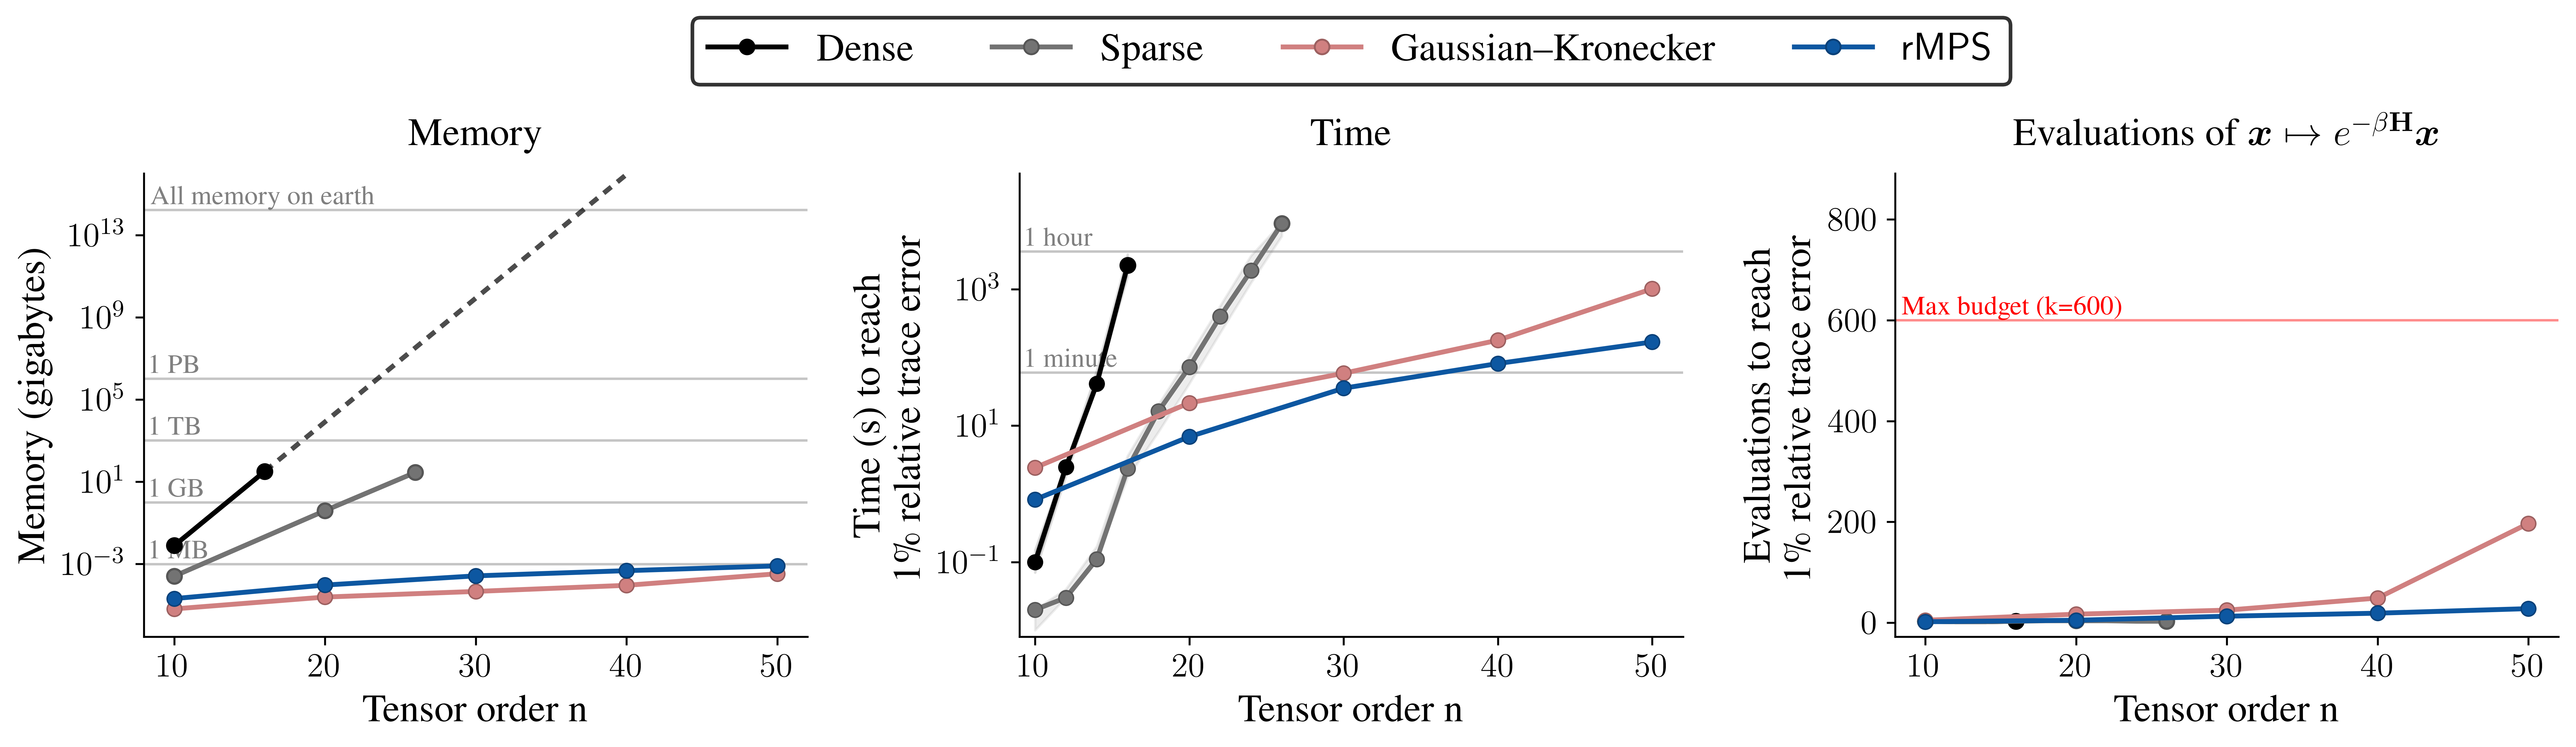

In [10]:
print_hit_rate_table(out)

extrapolate = False

fig_new, axes_new = plot_racedriver_memory_time(
    out,
    cmap                = "Blues",
    cmap_lo             = 0.4,
    cmap_hi             = 0.85,
    
    mode                = "median_quantile",
    marker_every        = 1,
    dense_upperbound_n  = 16,
    sparse_upperbound_n = 26,
    dense_sparse_json   = DENSE_SPARSE_JSON,
    kmax                = kmax,
    budget_time_s       = 60.0,
    extrapolate         = extrapolate,
    show                = True,
)
# fig_new.savefig(_HERE / "figures" / "Fig1_new.pdf", bbox_inches="tight")